#Section 1 - Environment Setup

In [1]:
import torch

print("PyTorch Version:", torch.__version__)
print("GPU Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

PyTorch Version: 2.11.0+cu128
GPU Available: True
GPU Name: Tesla T4


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

project_dir = "/content/drive/MyDrive/RemoteSensing_Internship"
os.makedirs(project_dir, exist_ok=True)
print("Project directory:", project_dir)

Project directory: /content/drive/MyDrive/RemoteSensing_Internship


In [4]:
%cd /content/drive/MyDrive/RemoteSensing_Internship

/content/drive/MyDrive/RemoteSensing_Internship


In [5]:
!pip install -q timm kagglehub

#Section 2 - Dataset(NWPU-RESISC45)

In [6]:
import kagglehub

path = kagglehub.dataset_download("aqibrehmanpirzada/nwpuresisc45")
print("Dataset downloaded to:", path)

100%|██████████| 408M/408M [00:06<00:00, 65.3MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/aqibrehmanpirzada/nwpuresisc45/versions/1


In [7]:
train_dir = os.path.join(path, "Dataset", "train", "train")
test_dir = os.path.join(path, "Dataset", "test", "test")

print("Train dir:", train_dir)
print("Test dir:", test_dir)

Train dir: /root/.cache/kagglehub/datasets/aqibrehmanpirzada/nwpuresisc45/versions/1/Dataset/train/train
Test dir: /root/.cache/kagglehub/datasets/aqibrehmanpirzada/nwpuresisc45/versions/1/Dataset/test/test


In [8]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import ConcatDataset, DataLoader, random_split

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_part = ImageFolder(root=train_dir, transform=transform)
test_part = ImageFolder(root=test_dir, transform=transform)

assert train_part.classes == test_part.classes, "Class mismatch between train and test folders!"

dataset = ConcatDataset([train_part, test_part])
class_names = train_part.classes

print("Total Images:", len(dataset))
print("Number of Classes:", len(class_names))

Total Images: 31500
Number of Classes: 45


In [9]:
dataset_size = len(dataset)
train_size = int(0.8 * dataset_size)
val_size = int(0.1 * dataset_size)
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print("Training Images:", len(train_dataset))
print("Validation Images:", len(val_dataset))
print("Testing Images:", len(test_dataset))

Training Images: 25200
Validation Images: 3150
Testing Images: 3150


In [10]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

images, labels = next(iter(train_loader))
print("Image Batch Shape:", images.shape)
print("Label Batch Shape:", labels.shape)

Image Batch Shape: torch.Size([32, 3, 224, 224])
Label Batch Shape: torch.Size([32])


#Section 3 - EfficientNet-B0 Model Setup


In [11]:
import torch.nn as nn
import timm

NUM_CLASSES = len(class_names)   # 45 for NWPU-RESISC45

model = timm.create_model(
    "efficientnet_b0",
    pretrained=True,
    num_classes=NUM_CLASSES
)

print(model.default_cfg)

model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

model.safetensors: downloading bytes:           |  0.00B            

{'url': 'https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-weights/efficientnet_b0_ra-3dd342df.pth', 'hf_hub_id': 'timm/efficientnet_b0.ra_in1k', 'architecture': 'efficientnet_b0', 'tag': 'ra_in1k', 'custom_load': False, 'input_size': (3, 224, 224), 'fixed_input_size': False, 'interpolation': 'bicubic', 'crop_pct': 0.875, 'crop_mode': 'center', 'mean': (0.485, 0.456, 0.406), 'std': (0.229, 0.224, 0.225), 'num_classes': 1000, 'pool_size': (7, 7), 'first_conv': 'conv_stem', 'classifier': 'classifier', 'license': 'apache-2.0'}


In [12]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

Total Parameters: 4,065,193
Trainable Parameters: 4,065,193


In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(device)

cuda


#Section 4 - Training Setup

In [14]:
criterion = nn.CrossEntropyLoss()
print(criterion)

CrossEntropyLoss()


In [15]:
import torch.optim as optim

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print(optimizer)

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)


In [16]:
scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=7,
    gamma=0.1
)

print(scheduler)

#Section 5 - Training Loop


In [17]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

In [18]:
EPOCHS = 15

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

In [19]:
best_accuracy = 0
import time

start_time = time.time()

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )

    scheduler.step()

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Accuracy : {train_acc:.2f}%")
    print(f"Validation Loss : {val_loss:.4f}")
    print(f"Validation Accuracy : {val_acc:.2f}%")
    print("-"*40)

    if val_acc > best_accuracy:
        best_accuracy = val_acc
        torch.save(model.state_dict(), "best_efficientnet_nwpu45.pth")

end_time = time.time()
training_time = end_time - start_time

print(f"Training Time: {training_time:.2f} seconds")
print("Training Finished!")
print("Best Validation Accuracy:", best_accuracy)

Epoch 1/15
Train Loss : 0.9117
Train Accuracy : 75.58%
Validation Loss : 0.3073
Validation Accuracy : 91.11%
----------------------------------------
Epoch 2/15
Train Loss : 0.1905
Train Accuracy : 94.21%
Validation Loss : 0.2340
Validation Accuracy : 92.86%
----------------------------------------
Epoch 3/15
Train Loss : 0.0817
Train Accuracy : 97.71%
Validation Loss : 0.2101
Validation Accuracy : 93.62%
----------------------------------------
Epoch 4/15
Train Loss : 0.0460
Train Accuracy : 98.69%
Validation Loss : 0.2000
Validation Accuracy : 94.10%
----------------------------------------
Epoch 5/15
Train Loss : 0.0332
Train Accuracy : 99.04%
Validation Loss : 0.2184
Validation Accuracy : 93.97%
----------------------------------------
Epoch 6/15
Train Loss : 0.0295
Train Accuracy : 99.15%
Validation Loss : 0.2190
Validation Accuracy : 94.10%
----------------------------------------
Epoch 7/15
Train Loss : 0.0257
Train Accuracy : 99.34%
Validation Loss : 0.2307
Validation Accuracy 

#Section 6 - Evaluation

In [20]:
model.load_state_dict(torch.load("best_efficientnet_nwpu45.pth"))
model.eval()
print("Best model loaded successfully!")

Best model loaded successfully!


In [21]:
test_loss, test_accuracy = evaluate(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 0.1650
Test Accuracy: 95.65%


In [22]:
import torch.nn.functional as F

all_preds = []
all_labels = []
all_probs = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

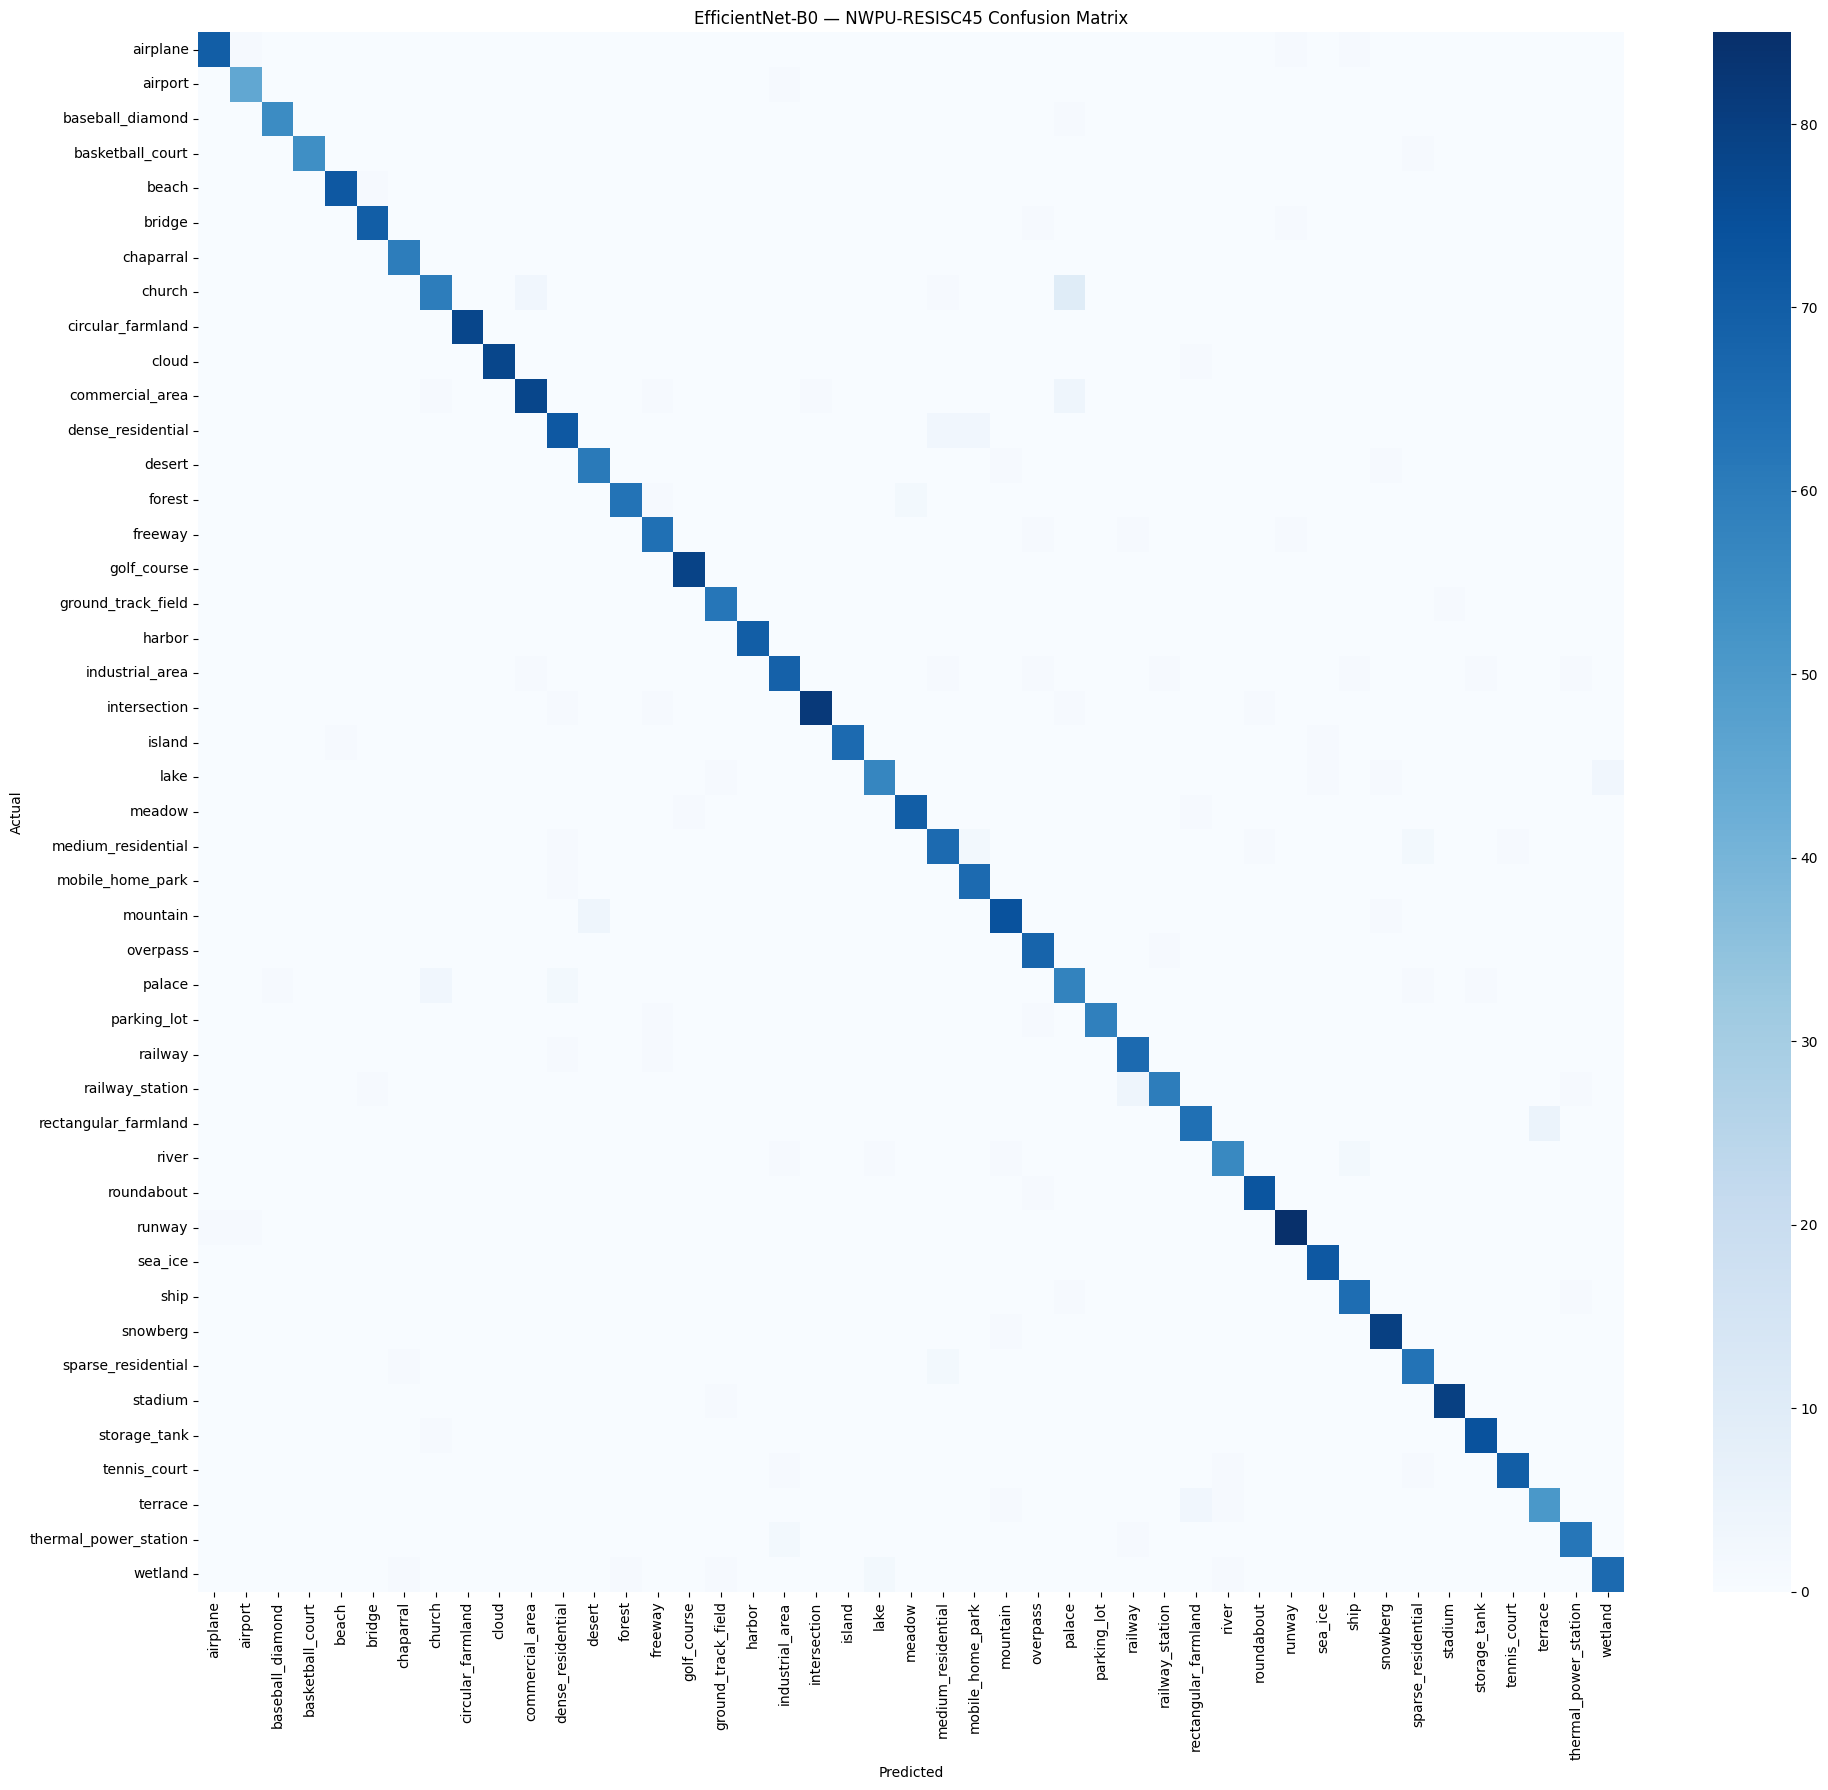

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(20, 18))
sns.heatmap(
    cm,
    annot=False,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("EfficientNet-B0 — NWPU-RESISC45 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [24]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds, target_names=class_names))

                       precision    recall  f1-score   support

             airplane       0.99      0.96      0.97        73
              airport       0.96      0.98      0.97        46
     baseball_diamond       0.98      0.98      0.98        56
     basketball_court       1.00      0.98      0.99        55
                beach       0.99      0.99      0.99        73
               bridge       0.97      0.97      0.97        72
            chaparral       0.97      1.00      0.98        60
               church       0.92      0.81      0.86        74
    circular_farmland       1.00      1.00      1.00        78
                cloud       1.00      0.99      0.99        79
      commercial_area       0.95      0.92      0.93        85
    dense_residential       0.92      0.92      0.92        78
               desert       0.94      0.97      0.95        63
               forest       0.98      0.95      0.97        66
              freeway       0.93      0.96      0.94  

In [25]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')
f1 = f1_score(all_labels, all_preds, average='macro')
auc = roc_auc_score(all_labels, np.array(all_probs), multi_class='ovr', average='macro')

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"AUC       : {auc:.4f}")

Precision : 0.9565
Recall    : 0.9565
F1 Score  : 0.9562
AUC       : 0.9994


#Section 7 - Training Curves


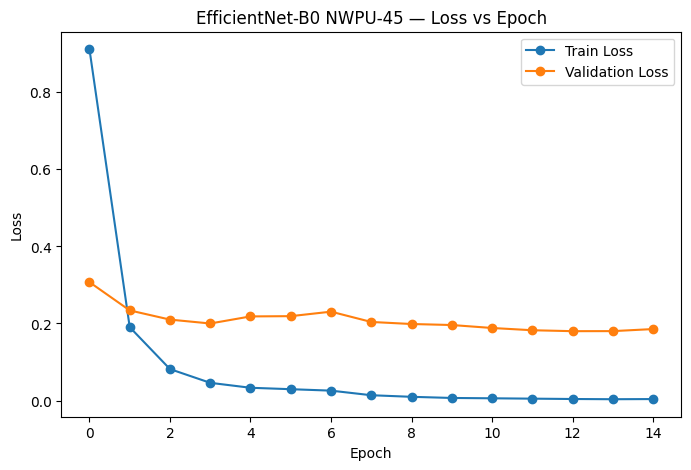

In [26]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, marker='o', label="Train Loss")
plt.plot(val_losses, marker='o', label="Validation Loss")
plt.title("EfficientNet-B0 NWPU-45 — Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

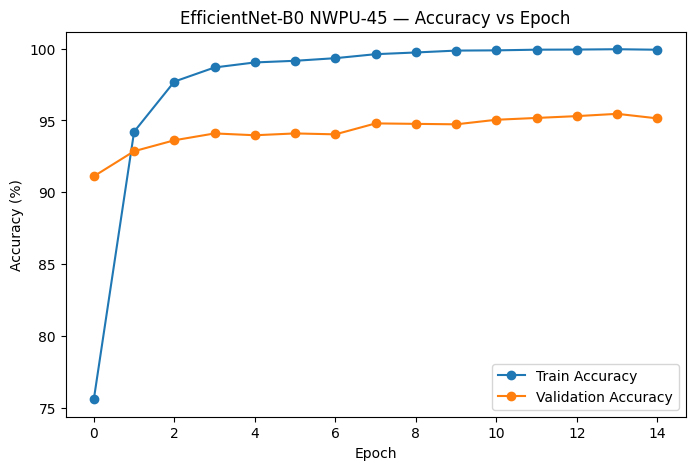

In [27]:
plt.figure(figsize=(8,5))
plt.plot(train_accuracies, marker='o', label="Train Accuracy")
plt.plot(val_accuracies, marker='o', label="Validation Accuracy")
plt.title("EfficientNet-B0 NWPU-45 — Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()

#Section 8 — Results Summary


In [28]:
print("="*50)
print("EfficientNet-B0 Results — NWPU-RESISC45")
print("="*50)
print(f"Training Time : {training_time:.2f} sec")
print(f"Training Loss : {train_losses[-1]:.4f}")
print(f"Validation Loss : {val_losses[-1]:.4f}")
print(f"Training Accuracy : {train_accuracies[-1]:.2f}%")
print(f"Validation Accuracy : {val_accuracies[-1]:.2f}%")
print(f"Test Accuracy : {test_accuracy:.2f}%")
print(f"Precision : {precision:.4f}")
print(f"Recall : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"AUC : {auc:.4f}")

EfficientNet-B0 Results — NWPU-RESISC45
Training Time : 2225.16 sec
Training Loss : 0.0039
Validation Loss : 0.1855
Training Accuracy : 99.92%
Validation Accuracy : 95.14%
Test Accuracy : 95.65%
Precision : 0.9565
Recall : 0.9565
F1 Score : 0.9562
AUC : 0.9994
